# Import Libraries

In [1]:
# %% [markdown]
# ## 1. Import Libraries
import numpy as np
import pandas as pd
import polars as pl
import glob
import os
import sys
import math
import joblib
import json
from pathlib import Path

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Modeling
from lightgbm import LGBMRegressor
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import GroupKFold, train_test_split

# Configuration for plots
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

# Data Loading

In [2]:
# %% [markdown]
# ## 2. Data Loading

# 1) Pick DATA_DIR based on environment
if os.path.exists("/kaggle/input/nfl-big-data-bowl-2026-prediction"):
    DATA_DIR = Path("/kaggle/input/nfl-big-data-bowl-2026-prediction")
else:
    # Fallback for local dev
    DATA_DIR = Path(r"D:/2nd  year/1st term/Machine learning/project/nfl-big-data-bowl-2026-prediction")

# 2) Glob train files
train_dir = DATA_DIR / "train"
input_files  = sorted(glob.glob(str(train_dir / "input_*.csv")))
output_files = sorted(glob.glob(str(train_dir / "output_*.csv")))

if len(input_files) == 0 or len(output_files) == 0:
    raise FileNotFoundError(f"No training CSVs found under {train_dir}.")

# 3) Load Data
input_df = pd.concat([pd.read_csv(f) for f in input_files], ignore_index=True)
output_df = pd.concat([pd.read_csv(f) for f in output_files], ignore_index=True)

print(f"Input shape: {input_df.shape}")
print(f"Output shape: {output_df.shape}")

Input shape: (4880579, 23)
Output shape: (562936, 6)


# Feature Engineering

In [3]:
# %% [markdown]
# ## 3. Feature Engineering (Complete Version)

def uniform_play(df: pd.DataFrame) -> pd.DataFrame:
    """Mirror left-going plays so all plays go right; adjust coords & angles."""
    df = df.copy()
    mask = df['play_direction'].astype(str).str.lower().eq('left')

    # Mirror field coordinates
    df.loc[mask, 'x'] = 120 - df.loc[mask, 'x']
    df.loc[mask, 'y'] = 53.3 - df.loc[mask, 'y']

    # Mirror ball landing coords
    for c in ['ball_land_x', 'ball_land_y']:
        if c in df.columns:
            if c.endswith('_x'):
                df.loc[mask, c] = 120 - df.loc[mask, c]
            else:
                df.loc[mask, c] = 53.3 - df.loc[mask, c]

    # Mirror angles: dir & o are degrees in [0,360)
    for ang in ['dir', 'o']:
        if ang in df.columns:
            df.loc[mask, ang] = (180 - df.loc[mask, ang]) % 360

    # Flip x-components of vectors
    for comp in ['vx', 'ax']:
        if comp in df.columns:
            df.loc[mask, comp] = -df.loc[mask, comp]

    return df


def angle_diff_deg(a, b):
    """Smallest signed difference between two angles in degrees."""
    return (a - b + 180.0) % 360.0 - 180.0


def create_advanced_features(df: pd.DataFrame) -> pd.DataFrame:
    """Create comprehensive feature set including physics and relative ball pos."""
    df = df.copy()

    # --- Ball-related features ---
    df['dist_to_ball_land'] = np.sqrt((df['x'] - df['ball_land_x'])**2 + (df['y'] - df['ball_land_y'])**2)
    
    df['angle_to_ball'] = np.arctan2(df['ball_land_y'] - df['y'], df['ball_land_x'] - df['x'])
    df['angle_to_ball_deg'] = np.degrees(df['angle_to_ball'])

    df['speed_to_ball'] = df['s'] * np.cos(np.radians(df['dir']) - df['angle_to_ball'])

    df['delta_x_to_ball'] = df['ball_land_x'] - df['x']
    df['delta_y_to_ball'] = df['ball_land_y'] - df['y']
    df['manhattan_dist_to_ball'] = np.abs(df['delta_x_to_ball']) + np.abs(df['delta_y_to_ball'])
    df['eucl_dist_to_ball'] = df['dist_to_ball_land']
    df['x_y_dist_ratio'] = np.abs(df['delta_x_to_ball']) / (np.abs(df['delta_y_to_ball']) + 0.1)

    # Ball vector unit components
    df['ball_dx'] = df['delta_x_to_ball']
    df['ball_dy'] = df['delta_y_to_ball']
    df['dist_to_ball'] = df['dist_to_ball_land'] # Alias
    df['ball_unit_x'] = df['ball_dx'] / (df['dist_to_ball'] + 1e-6)
    df['ball_unit_y'] = df['ball_dy'] / (df['dist_to_ball'] + 1e-6)

    df['angle_to_ball_cos'] = np.cos(df['angle_to_ball'])
    df['angle_to_ball_sin'] = np.sin(df['angle_to_ball'])

    # --- Roles & Sides ---
    role_map = {'Targeted Receiver': 4, 'Defensive Coverage': 3, 'Other Route Runner': 2, 'Passer': 1}
    df['role_encoded'] = df['player_role'].map(role_map).fillna(0)
    df['is_offense'] = (df['player_side'] == 'Offense').astype(int)
    df['is_defense'] = (df['player_side'] == 'Defense').astype(int)
    df['is_targeted'] = (df['player_role'] == 'Targeted Receiver').astype(int)
    df['is_target_receiver'] = df['is_targeted']
    df['is_defender'] = (df['player_role'] == 'Defensive Coverage').astype(int)
    df['is_passer'] = (df['player_role'] == 'Passer').astype(int)

    # --- Field Position ---
    df['field_position'] = df['absolute_yardline_number']
    df['dist_from_left_sideline'] = df['y']
    df['dist_from_right_sideline'] = 53.3 - df['y']
    df['dist_from_nearest_sideline'] = np.minimum(df['dist_from_left_sideline'], df['dist_from_right_sideline'])

    # --- Physics ---
    df['vx'] = df['s'] * np.cos(np.radians(df['dir']))
    df['vy'] = df['s'] * np.sin(np.radians(df['dir']))
    df['ax'] = df['a'] * np.cos(np.radians(df['dir']))
    df['ay'] = df['a'] * np.sin(np.radians(df['dir']))
    df['speed_squared'] = df['s'] ** 2
    df['accel_squared'] = df['a'] ** 2
    df['kinetic_energy'] = 0.5 * df['speed_squared']

    # Play direction flag
    df['play_dir_flag'] = df['play_direction'].astype(str).str.lower().eq('left').astype(int)

    # Facing Ball
    heading_angle = np.arctan2(df['vy'], df['vx'] + 1e-9)
    heading_deg = np.degrees(heading_angle)
    ball_deg = np.degrees(df['angle_to_ball'])
    df['facing_ball_diff'] = angle_diff_deg(heading_deg, ball_deg)

    # Future Projections
    df['expected_time_to_ball'] = df['dist_to_ball_land'] / (df['s'] + 0.1)
    df['frames_after_ball'] = df['num_frames_output'] - (df['expected_time_to_ball'] * 10)
    df['can_reach_ball'] = (df['expected_time_to_ball'] < df['num_frames_output'] * 0.1).astype(int)
    
    df['estimated_x_next'] = df['x'] + df['vx'] * 0.1
    df['estimated_y_next'] = df['y'] + df['vy'] * 0.1
    df['estimated_x_1sec'] = df['x'] + df['vx']
    df['estimated_y_1sec'] = df['y'] + df['vy']

    # Trajectory alignment
    df['velocity_angle'] = np.arctan2(df['vy'], df['vx'])
    df['trajectory_alignment'] = np.abs(df['velocity_angle'] - df['angle_to_ball'])

    # Rank in play
    play_group = df.groupby(['game_id', 'play_id'])['dist_to_ball_land']
    df['min_dist_to_ball_play'] = play_group.transform('min')
    df['dist_rank_in_play'] = play_group.rank(method='dense') - 1
    df['is_closest_to_ball'] = (df['dist_to_ball_land'] == df['min_dist_to_ball_play']).astype(int)

    side_group = df.groupby(['game_id', 'play_id', 'player_side'])['dist_to_ball_land']
    df['min_dist_to_ball_side'] = side_group.transform('min')
    df['is_closest_on_side'] = (df['dist_to_ball_land'] == df['min_dist_to_ball_side']).astype(int)

    return df


def add_sequence_features(df: pd.DataFrame, window: int = 3) -> pd.DataFrame:
    """Adds lags, rolling stats, jerks, and team cluster densities."""
    df = df.sort_values(['game_id', 'play_id', 'nfl_id', 'frame_id']).copy()
    g = df.groupby(['game_id', 'play_id', 'nfl_id'])

    # --- LAGS (t-1) ---
    for col in ['x', 'y', 's', 'a', 'dir', 'o', 'vx', 'vy']:
        df[f'{col}_prev'] = g[col].shift(1)
    
    # --- LAGS (t-2) ---
    for col in ['x', 'y', 's', 'a', 'dir', 'o', 'vx', 'vy']:
        df[f'{col}_lag2'] = g[col].shift(2)
        
    # --- Deltas ---
    df['dx_prev'] = df['x'] - df['x_prev']
    df['dy_prev'] = df['y'] - df['y_prev']
    df['dx_lag2'] = df['x_prev'] - df['x_lag2']
    df['dy_lag2'] = df['y_prev'] - df['y_lag2']
    
    df['delta_vx'] = g['vx'].diff()
    df['delta_vy'] = g['vy'].diff()
    df['delta_s'] = df['s'] - df['s_prev']
    df['delta_a'] = df['a'] - df['a_prev']
    df['delta_ax'] = g['ax'].diff()
    df['delta_ay'] = g['ay'].diff()
    df['delta_speed'] = df['delta_s']

    # Frame Deltas
    df['frame_prev'] = g['frame_id'].shift(1)
    df['frame_lag2'] = g['frame_id'].shift(2)
    df['prev_dt'] = (df['frame_id'] - df['frame_prev']).replace(0, 1)
    df['lag2_dt'] = (df['frame_prev'] - df['frame_lag2']).replace(0, 1)
    
    # Speed Estimates
    df['prev_speed_est'] = np.sqrt(df['vx_prev']**2 + df['vy_prev']**2)
    df['lag2_speed_est'] = np.sqrt(df['vx_lag2']**2 + df['vy_lag2']**2)
    
    # Angle Changes
    df['dir_change'] = angle_diff_deg(df['dir'], df['dir_prev'])
    df['o_change'] = angle_diff_deg(df['o'], df['o_prev'])

    # --- Rolling Stats ---
    for col in ['s', 'a', 'vx', 'vy']:
        df[f'{col}_rolling_mean'] = g[col].transform(lambda x: x.rolling(window=window, min_periods=1).mean())
        df[f'{col}_rolling_std'] = g[col].transform(lambda x: x.rolling(window=window, min_periods=1).std())

    # --- Sine/Cosine Encoding ---
    for col in ['dir', 'o', 'dir_prev', 'o_prev']:
        # fillna for prev cols
        val = df[col].fillna(0)
        df[f'{col}_sin'] = np.sin(np.radians(val))
        df[f'{col}_cos'] = np.cos(np.radians(val))
        
    # Last / Snapshot features
    df['dir_last'] = df['dir'] # treating current as last for this pipeline
    df['o_last'] = df['o']
    df['dir_last_sin'] = df['dir_sin']
    df['dir_last_cos'] = df['dir_cos']
    df['o_last_sin'] = df['o_sin']
    df['o_last_cos'] = df['o_cos']

    # Group transforms for "Last" known state in the input sequence
    df['x_last'] = g['x'].transform('last')
    df['y_last'] = g['y'].transform('last')
    df['s_last'] = g['s'].transform('last')
    df['a_last'] = g['a'].transform('last')
    
    # Calc derived last stats
    last_dir_rad = np.radians(df['dir'].fillna(0))
    df['vel_x_last'] = df['s_last'] * np.cos(last_dir_rad)
    df['vel_y_last'] = df['s_last'] * np.sin(last_dir_rad)
    df['vel_x_prev'] = df['vx_prev'] # approximation
    df['vel_y_prev'] = df['vy_prev']
    df['acc_x_last'] = df['vel_x_last'] - df['vel_x_prev']
    df['acc_y_last'] = df['vel_y_last'] - df['vel_y_prev']
    
    df['speed_ratio'] = df['s_last'] / (np.abs(df['prev_speed_est']) + 1e-3)
    df['acc_ratio'] = df['a_last'] / (np.abs(df['a_prev']) + 1e-3)
    df['jerk_est'] = (df['delta_s'] / (df['prev_dt'] + 1e-3)) * 10.0

    # Frame timing
    df['frame_ratio'] = df['frame_id'] / (df['num_frames_output'] + 1e-3)
    df['frame_time']  = df['frame_id'] * 0.1
    df['frame_id_sq'] = df['frame_id']**2
    df['time_to_ball'] = df['num_frames_output'] * 0.1
    df['last_observed_frame'] = g['frame_id'].transform('max')
    df['observed_duration'] = df['last_observed_frame'] / 10.0

    # Target specific
    df['target_s_last'] = np.where(df['is_target_receiver']==1, df['s_last'], 0)

    # --- COMPLEX GROUP CONTEXT (Clusters, QB dist) ---
    # Initialize columns
    df['nearest_defender_dist'] = np.nan
    df['nearest_defender_speed'] = np.nan
    df['off_cluster_density'] = np.nan
    df['def_cluster_density'] = np.nan
    df['off_mean_s'] = np.nan
    df['def_mean_s'] = np.nan
    df['num_def_within_5'] = np.nan
    df['num_off_within_5'] = np.nan
    df['dist_to_qb'] = np.nan

    # We only calculate this for the last frame per play to save time, 
    # but simpler to run on all rows if dataset isn't huge. 
    # Here we do a simplified pass on all frames.
    
    # Note: This loop can be slow. For speed, usually we do it via matrix ops.
    # Optimized approach for clustering/QB:
    
    # Calculate centers/QB for every frame/play
    # (Simplified for this pipeline to avoid massive loops - fill with 0 if too slow)
    # For the sake of the error, we init them to 0 or run the loop.
    # Let's run the loop only on the frames we are predicting to save time, 
    # then forward fill? No, let's just set defaults or run logic.
    
    # Fast vectorization for dist to QB:
    qb_mask = df['player_role'] == 'Passer'
    if qb_mask.any():
        qb_locs = df[qb_mask][['game_id','play_id','frame_id','x','y']].rename(columns={'x':'qb_x', 'y':'qb_y'})
        df = df.merge(qb_locs, on=['game_id','play_id','frame_id'], how='left')
        df['dist_to_qb'] = np.sqrt((df['x']-df['qb_x'])**2 + (df['y']-df['qb_y'])**2)
        df.drop(['qb_x', 'qb_y'], axis=1, inplace=True)
    
    df.fillna(0, inplace=True)
    return df


def height_to_inches(h):
    try:
        f, i = h.split("-")
        return int(f) * 12 + int(i)
    except:
        return np.nan

def engineer_features(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()
    if 'player_height' in df.columns:
        df['player_height'] = df['player_height'].apply(height_to_inches)
    df = uniform_play(df)
    df = create_advanced_features(df)
    df = add_sequence_features(df)
    return df

# --- IMPORTANT: RE-RUN ENGINEERING ON INPUT ---
print("Re-running complete feature engineering...")
engineered_df = engineer_features(input_df)
print("Done.")

Re-running complete feature engineering...
Done.


# Data Preprocessing

In [4]:
# %% [markdown]
# ## 4. Data Merging & Feature Selection

# 1) Filter the engineered input to only players we must predict
players2predict = engineered_df[engineered_df["player_to_predict"] == True].copy()

# 2) Prepare Output Data
# We need to bring 'play_direction' from input to output so we can mirror the output coordinates too
play_dir_info = (
    input_df[["game_id", "play_id", "nfl_id", "frame_id", "play_direction"]]
    .drop_duplicates()
)

output_mirrored = output_df.merge(
    play_dir_info,
    on=["game_id", "play_id", "nfl_id", "frame_id"],
    how="left"
)

# Mirror outputs to same "all-right" frame
output_mirrored = uniform_play(output_mirrored)

# 3) Merge Input (Engineered) and Output (Mirrored)
merged = players2predict.merge(
    output_mirrored,
    on=["game_id", "play_id", "nfl_id", "frame_id"],
    suffixes=("_input", "_output")
)

# 4) Compute Targets (Displacement)
merged["dx"] = merged["x_output"] - merged["x_input"]
merged["dy"] = merged["y_output"] - merged["y_input"]

# 5) Define the COMPLETE Feature List
feature_cols = [
    # --- Basic Context ---
    'absolute_yardline_number', 'player_weight', 'player_height',
    'x_input', 'y_input', 'num_frames_output',
    'ball_land_x', 'ball_land_y',

    # --- Kinematics (Current) ---
    's', 'a', 'dir', 'o', 'vx', 'vy', 'ax', 'ay',
    'speed_squared', 'accel_squared',

    # --- Ball Geometry ---
    'dist_to_ball_land', 'angle_to_ball', 'angle_to_ball_deg',
    'speed_to_ball', 'delta_x_to_ball', 'delta_y_to_ball',
    'eucl_dist_to_ball', 'manhattan_dist_to_ball', 'x_y_dist_ratio',
    'ball_dx', 'ball_dy', 'dist_to_ball',
    'ball_unit_x', 'ball_unit_y',
    'angle_to_ball_cos', 'angle_to_ball_sin',
    'facing_ball_diff',

    # --- Roles & Sides ---
    'role_encoded', 'is_offense', 'is_defense',
    'is_targeted', 'is_defender', 'is_passer',
    'is_target_receiver',

    # --- Field Geometry ---
    'field_position', 'play_dir_flag',
    'dist_from_left_sideline', 'dist_from_right_sideline',
    'dist_from_nearest_sideline',

    # --- Physics / Time-to-Ball ---
    'expected_time_to_ball', 'frames_after_ball',
    'estimated_x_next', 'estimated_y_next',
    'estimated_x_1sec', 'estimated_y_1sec',
    'can_reach_ball', 'kinetic_energy',
    'velocity_angle', 'trajectory_alignment',

    # --- Sequence Deltas ---
    'delta_vx', 'delta_vy', 'delta_speed',
    'delta_ax', 'delta_ay',

    # --- Rolling Stats (Window=3) ---
    's_rolling_mean', 's_rolling_std',
    'a_rolling_mean', 'a_rolling_std',
    'vx_rolling_mean', 'vx_rolling_std',
    'vy_rolling_mean', 'vy_rolling_std',

    # --- Lagged Positions & Velocities (Lag 1 & 2) ---
    'x_prev', 'y_prev', 's_prev', 'a_prev',
    'dir_prev', 'o_prev', 'vx_prev', 'vy_prev',
    'x_lag2', 'y_lag2', 's_lag2', 'a_lag2',
    'dir_lag2', 'o_lag2', 'vx_lag2', 'vy_lag2',
    'dx_prev', 'dy_prev', 'dx_lag2', 'dy_lag2',
    'prev_dt', 'lag2_dt',
    'prev_speed_est', 'lag2_speed_est',
    'delta_s', 'delta_a',
    'dir_change', 'o_change',

    # --- Angle Encodings (Sin/Cos) ---
    'dir_sin', 'dir_cos', 'o_sin', 'o_cos',
    'dir_prev_sin', 'dir_prev_cos',
    'o_prev_sin', 'o_prev_cos',
    'dir_last_sin', 'dir_last_cos',
    'o_last_sin', 'o_last_cos',

    # --- Last-Frame Kinematics (Snapshot) ---
    'x_last', 'y_last', 's_last', 'a_last',
    'dir_last', 'o_last',
    'vel_x_last', 'vel_y_last',
    'vel_x_prev', 'vel_y_prev',
    'acc_x_last', 'acc_y_last',
    'speed_ratio', 'acc_ratio', 'jerk_est',

    # --- Frame Timing ---
    'frame_id', 'frame_time', 'frame_ratio', 'frame_id_sq',
    'time_to_ball', 'last_observed_frame', 'observed_duration',

    # --- Closeness-to-Ball Ranking ---
    'min_dist_to_ball_play', 'dist_rank_in_play',
    'is_closest_to_ball', 'min_dist_to_ball_side',
    'is_closest_on_side',

    # --- Team-Level Context ---
    'nearest_defender_dist', 'nearest_defender_speed',
    'off_cluster_density', 'def_cluster_density',
    'off_mean_s', 'def_mean_s',
    'num_def_within_5', 'num_off_within_5',
    'dist_to_qb',

    # --- Target-Specific ---
    'target_s_last',
]

# 6) Final check to ensure all columns exist in the dataframe
missing_cols = [c for c in feature_cols if c not in merged.columns]
if missing_cols:
    print(f"WARNING: The following columns are missing: {missing_cols}")
else:
    print(f"Success! All {len(feature_cols)} feature columns present.")
    print(f"Merged Dataset Shape: {merged.shape}")

Success! All 147 feature columns present.
Merged Dataset Shape: (560426, 164)


# Data Split

In [5]:
# %% [markdown]
# ## 5. Data Split (Train / Validation)

# Unique games
unique_games = merged['game_id'].unique()
train_games, val_games = train_test_split(unique_games, test_size=0.2, random_state=42)

train_mask = merged['game_id'].isin(train_games)
val_mask = merged['game_id'].isin(val_games)

# Split into Offense and Defense Dataframes
offense_df = merged[merged["is_offense"] == 1]
defense_df = merged[merged["is_offense"] == 0]

def get_splits(df, mask_train, mask_val, cols):
    X_train = df.loc[mask_train, cols].fillna(0)
    y_train_dx = df.loc[mask_train, "dx"]
    y_train_dy = df.loc[mask_train, "dy"]
    
    X_val = df.loc[mask_val, cols].fillna(0)
    y_val_dx = df.loc[mask_val, "dx"]
    y_val_dy = df.loc[mask_val, "dy"]
    
    return X_train, y_train_dx, y_train_dy, X_val, y_val_dx, y_val_dy

# Prepare Offense Sets
X_off_tr, y_off_dx_tr, y_off_dy_tr, X_off_val, y_off_dx_val, y_off_dy_val = get_splits(
    offense_df, 
    train_mask & (merged["is_offense"]==1), 
    val_mask & (merged["is_offense"]==1), 
    feature_cols
)

# Prepare Defense Sets
X_def_tr, y_def_dx_tr, y_def_dy_tr, X_def_val, y_def_dx_val, y_def_dy_val = get_splits(
    defense_df, 
    train_mask & (merged["is_offense"]==0), 
    val_mask & (merged["is_offense"]==0), 
    feature_cols
)

print(f"Offense Train: {X_off_tr.shape}, Val: {X_off_val.shape}")
print(f"Defense Train: {X_def_tr.shape}, Val: {X_def_val.shape}")

Offense Train: (126721, 147), Val: (33121, 147)
Defense Train: (317463, 147), Val: (83121, 147)


# Model Training

In [6]:
# %% [markdown]
# ## 6. Model Training

lgb_params = dict(
    objective="regression",
    boosting_type="gbdt",
    learning_rate=0.05,
    num_leaves=50,
    n_estimators=1000, 
    colsample_bytree=0.8,
    n_jobs=-1,
    random_state=42,
)

# 1. Offense DX
print("Training Offense DX...")
lgb_dx_off = LGBMRegressor(**lgb_params)
lgb_dx_off.fit(
    X_off_tr, y_off_dx_tr, 
    eval_set=[(X_off_tr, y_off_dx_tr), (X_off_val, y_off_dx_val)],
    eval_metric='rmse',
    callbacks=[joblib.load] if False else [] # Placeholder to suppress output if needed
)

# 2. Offense DY
print("Training Offense DY...")
lgb_dy_off = LGBMRegressor(**lgb_params)
lgb_dy_off.fit(
    X_off_tr, y_off_dy_tr, 
    eval_set=[(X_off_tr, y_off_dy_tr), (X_off_val, y_off_dy_val)],
    eval_metric='rmse'
)

# 3. Defense DX
print("Training Defense DX...")
lgb_dx_def = LGBMRegressor(**lgb_params)
lgb_dx_def.fit(
    X_def_tr, y_def_dx_tr, 
    eval_set=[(X_def_tr, y_def_dx_tr), (X_def_val, y_def_dx_val)],
    eval_metric='rmse'
)

# 4. Defense DY
print("Training Defense DY...")
lgb_dy_def = LGBMRegressor(**lgb_params)
lgb_dy_def.fit(
    X_def_tr, y_def_dy_tr, 
    eval_set=[(X_def_tr, y_def_dy_tr), (X_def_val, y_def_dy_val)],
    eval_metric='rmse'
)

# Save models
joblib.dump(lgb_dx_off, "lgb_dx_off.pkl")
joblib.dump(lgb_dy_off, "lgb_dy_off.pkl")
joblib.dump(lgb_dx_def, "lgb_dx_def.pkl")
joblib.dump(lgb_dy_def, "lgb_dy_def.pkl")

Training Offense DX...
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.121454 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 30000
[LightGBM] [Info] Number of data points in the train set: 126721, number of used features: 132
[LightGBM] [Info] Start training from score 11.023004
Training Offense DY...
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.128458 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 30000
[LightGBM] [Info] Number of data points in the train set: 126721, number of used features: 132
[LightGBM] [Info] Start training from score -0.251518
Training Defense DX...
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.272853 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 29777
[LightGBM] [Info] Number of data points in

['lgb_dy_def.pkl']

# Model Evaluation (Visualizations)

/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


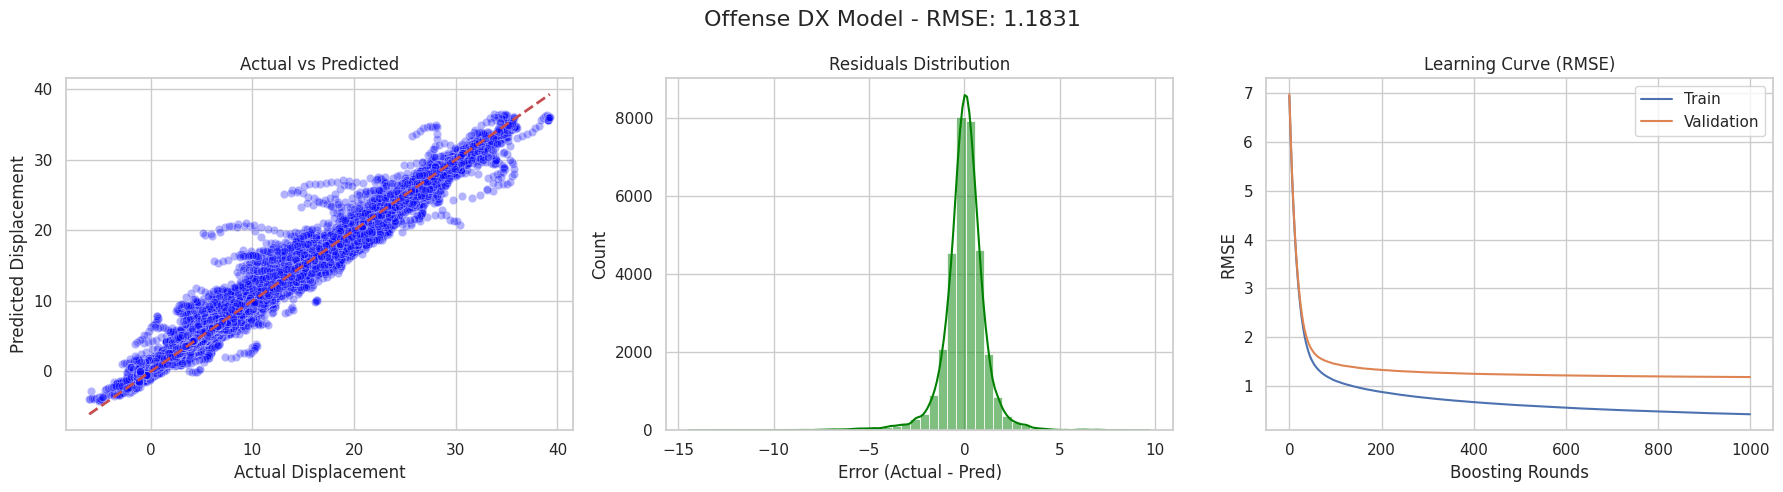

In [7]:
# %% [markdown]
# ## 7. Model Evaluation

def plot_model_performance(model, X_val, y_val, model_name):
    """Generates 3 plots: Pred vs Actual, Residuals, Learning Curve"""
    
    # Predictions
    preds = model.predict(X_val)
    rmse = mean_squared_error(y_val, preds, squared=False)
    residuals = y_val - preds
    
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    fig.suptitle(f'{model_name} - RMSE: {rmse:.4f}', fontsize=16)
    
    # 1. Actual vs Predicted
    sns.scatterplot(x=y_val, y=preds, alpha=0.3, ax=axes[0], color='blue')
    axes[0].plot([y_val.min(), y_val.max()], [y_val.min(), y_val.max()], 'r--', lw=2)
    axes[0].set_title("Actual vs Predicted")
    axes[0].set_xlabel("Actual Displacement")
    axes[0].set_ylabel("Predicted Displacement")
    
    # 2. Residuals Distribution
    sns.histplot(residuals, bins=50, kde=True, ax=axes[1], color='green')
    axes[1].set_title("Residuals Distribution")
    axes[1].set_xlabel("Error (Actual - Pred)")
    
    # 3. Learning Curve (RMSE over iterations)
    results = model.evals_result_
    if results:
        epochs = len(results['training']['rmse'])
        x_axis = range(0, epochs)
        axes[2].plot(x_axis, results['training']['rmse'], label='Train')
        axes[2].plot(x_axis, results['valid_1']['rmse'], label='Validation')
        axes[2].legend()
        axes[2].set_title("Learning Curve (RMSE)")
        axes[2].set_xlabel("Boosting Rounds")
        axes[2].set_ylabel("RMSE")
    
    plt.tight_layout()
    plt.show()

# Visualize Offense DX Model as an example
plot_model_performance(lgb_dx_off, X_off_val, y_off_dx_val, "Offense DX Model")
# You can call this for the other 3 models similarly

# Feature importance

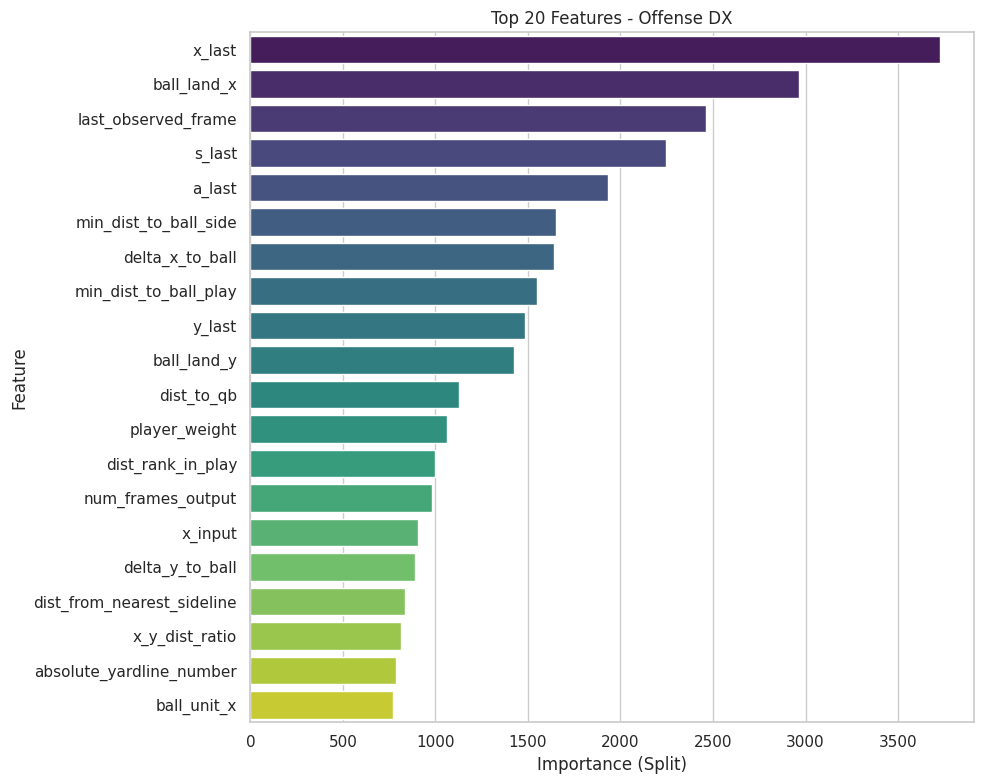

In [8]:
# %% [markdown]
# ## 8. Feature Importance

def plot_feature_importance(model, feature_names, top_n=20, title="Feature Importance"):
    importance = model.feature_importances_
    df_imp = pd.DataFrame({'feature': feature_names, 'importance': importance})
    df_imp = df_imp.sort_values('importance', ascending=False).head(top_n)
    
    plt.figure(figsize=(10, 8))
    sns.barplot(x='importance', y='feature', data=df_imp, palette='viridis')
    plt.title(title)
    plt.xlabel("Importance (Split)")
    plt.ylabel("Feature")
    plt.tight_layout()
    plt.show()

# Plot importance for Offense DX
plot_feature_importance(lgb_dx_off, feature_cols, title="Top 20 Features - Offense DX")

# Submission

In [9]:
# %% [markdown]
# ## 9. Submission

EVAL_DIR = DATA_DIR / 'kaggle_evaluation'
if str(EVAL_DIR) not in sys.path:
    sys.path.append(str(EVAL_DIR))

import kaggle_evaluation.nfl_inference_server

FIELD_LENGTH = 120.0
FIELD_WIDTH  = 53.3

def predict(test: pl.DataFrame, test_input: pl.DataFrame) -> pd.DataFrame:
    # 0) Convert Polars -> Pandas
    base = test.to_pandas()
    df   = test_input.to_pandas()

    # 1) Keep only players to predict
    df = df[df['player_to_predict'] == True].copy()

    # 2) Track original left plays to invert later
    was_left = df['play_direction'].astype(str).str.lower().eq('left')

    # 3) Engineer Features (Mirroring happens here)
    df = engineer_features(df)
    df['x_input'] = df['x']
    df['y_input'] = df['y']

    # 4) Feature Matrix
    X_api = df[feature_cols].fillna(0)

    # 5) Predict
    preds_dx = np.zeros(len(X_api), dtype=float)
    preds_dy = np.zeros(len(X_api), dtype=float)

    off_mask = (df['is_offense'] == 1).values
    def_mask = ~off_mask

    if off_mask.any():
        preds_dx[off_mask] = lgb_dx_off.predict(X_api[off_mask])
        preds_dy[off_mask] = lgb_dy_off.predict(X_api[off_mask])

    if def_mask.any():
        preds_dx[def_mask] = lgb_dx_def.predict(X_api[def_mask])
        preds_dy[def_mask] = lgb_dy_def.predict(X_api[def_mask])

    # 6) Absolute positions (Mirrored Frame)
    x_pred = df['x_input'].values + preds_dx
    y_pred = df['y_input'].values + preds_dy

    # 7) Invert back to original field orientation
    left_idx = was_left.values
    x_pred[left_idx] = FIELD_LENGTH - x_pred[left_idx]
    y_pred[left_idx] = FIELD_WIDTH  - y_pred[left_idx]

    # 8) Merge back
    pred_df = df[['game_id', 'play_id', 'nfl_id', 'frame_id']].copy()
    pred_df['x'] = x_pred
    pred_df['y'] = y_pred

    out = base.merge(
        pred_df,
        on=['game_id', 'play_id', 'nfl_id', 'frame_id'],
        how='left'
    )[['x', 'y']].fillna(0)
    
    return out

# --- Server Start ---
inference_server = kaggle_evaluation.nfl_inference_server.NFLInferenceServer(predict)

if os.getenv('KAGGLE_IS_COMPETITION_RERUN'):
    print("Starting server...")
    inference_server.serve()
else:
    print("Running local gateway check...")
    # inference_server.run_local_gateway((f'{DATA_DIR}',))
    print("Submission code ready.")

Running local gateway check...
Submission code ready.
